In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.load_run_data import load_run_data
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
import pickle
from tqdm import tqdm
from sklearn.linear_model import LinearRegression, Lasso, MultiTaskLasso, LassoCV, MultiTaskLassoCV

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut

from sklearn.metrics import r2_score

from analysis.utils import extract_variables
import pickle


In [10]:
data = load_run_data('logs/initial_conditions', add_frames=True, n_frames=1)

Found 9 episode directories in logs/initial_conditions
Loaded 9 episodes
Loaded 9 planning episodes


In [11]:
varsname_dict = {
    0: 'cart position',
    1: 'cos(pole angle)',
    2: 'sin(pole angle)',
    3: 'cart velocity',
    4: 'pole angular velocity',
}

varsname_dict_ext = {
    0: 'cart position',
    1: 'cos(pole angle)',
    2: 'sin(pole angle)',
    3: 'cart velocity',
    4: 'pole angular velocity',
    5: 'rewards',
    6: 'actions',
}

In [12]:
exp_vars = extract_variables(
    data,
    variables=['latent_states', 'observations', 'actions', 'rewards'],
    n_steps=500)

In [13]:
for var in exp_vars:
    print(f"{var}: {exp_vars[var][0].shape}")

latent_states: (500, 512)
observations: (500, 5)
actions: (500, 1)
rewards: (500, 1)


In [14]:
latents, observations, actions, rewards = (exp_vars['latent_states'],
                                           exp_vars['observations'],
                                           exp_vars['actions'],
                                           exp_vars['rewards'])

## Finding non-aligned spaces 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA, SparsePCA
from sklearn.preprocessing import StandardScaler


def analyze_latent_to_observation_mapping(Xs,
                                          Ys,
                                          method="pca",
                                          n_components=10):
    """
    observations: [T, D_obs]  -> e.g. DMControl proprioceptive states
    latents: [T, D_latent]    -> TD-MPC2 encoder outputs
    method: 'pca' or 'ica'
    obs_labels: optional list of observation names
    """
    # normalize latents for analysis
    #Z = StandardScaler().fit_transform(latents)
    #O = StandardScaler().fit_transform(observations)

    if method == "pca":
        model = PCA(n_components=n_components)
    elif method == "ica":
        model = FastICA(n_components=n_components, whiten="unit-variance")
    elif method == 'sparse_pca':
        model = SparsePCA(n_components=n_components, alpha=0.1)
    else:
        raise ValueError("method must be 'pca' or 'ica'")

    # Fit decomposition
    F = model.fit_transform(Xs)  # [T, n_components]
    comps = model.components_  # [n_components, D_latent]

    # Correlate each component with each observation variable
    corr_matrix = np.corrcoef(F.T, Ys.T)[:n_components, n_components:]

    # Get explained variance if available
    explained_variance = None
    if hasattr(model, 'explained_variance_ratio_'):
        explained_variance = model.explained_variance_ratio_
        print(f"Explained variance by component: {explained_variance}")
        print(f"Total explained variance: {explained_variance.sum():.3f}")

    return corr_matrix, comps, explained_variance


def plot_component_correlations(corr_matrix,
                                obs_labels=None,
                                title="Latent-Observation Map"):
    n_components, D_obs = corr_matrix.shape
    plt.figure(figsize=(12, 4))
    plt.imshow(corr_matrix, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation')
    plt.xlabel("Observation variables")
    plt.ylabel("Latent components")
    plt.title(title)
    if obs_labels:
        plt.xticks(range(D_obs), obs_labels, rotation=90)
    plt.tight_layout()
    plt.show()


In [20]:
np.concatenate(latents, axis=0).shape

(4500, 512)

In [38]:
latents_arr = np.concatenate(latents, axis=0)
observations_arr = np.concatenate(observations, axis=0)
rewards_arr = np.concatenate(rewards, axis=0)
actions_arr = np.concatenate(actions, axis=0)
all_arrs = np.concatenate([observations_arr, rewards_arr, actions_arr], axis=1)

corr_pca_all, comps_pca_all, exp_var_all = analyze_latent_to_observation_mapping(
    Xs=latents_arr,
    Ys=all_arrs,
    method="pca",
    n_components=10,
)

comps_pca_eps = []
for eps_idx in range(len(latents)):
    latent_eps = latents[eps_idx]
    obs_eps = observations[eps_idx]
    rew_eps = rewards[eps_idx]
    act_eps = actions[eps_idx]

    all_eps = np.concatenate([obs_eps, rew_eps, act_eps], axis=1)
    corr_pca, comps_pca, exp_var = analyze_latent_to_observation_mapping(
        Xs=latent_eps,
        Ys=all_eps,
        method="pca",
        n_components=10,
    )
    comps_pca_eps.append(comps_pca)

Explained variance by component: [0.45144928 0.10098703 0.07560262 0.0647897  0.05133219 0.04480707
 0.03502357 0.02855656 0.02360139 0.01804327]
Total explained variance: 0.894
Explained variance by component: [0.6167004  0.19039515 0.08272715 0.05855191 0.02120616 0.0130812
 0.00761992 0.0045397  0.0021395  0.00117223]
Total explained variance: 0.998
Explained variance by component: [0.60798246 0.19188774 0.09906564 0.05861196 0.01993462 0.00936974
 0.00590963 0.00311714 0.00172146 0.00082347]
Total explained variance: 0.998
Explained variance by component: [0.5932508  0.18711115 0.1110644  0.06273156 0.01961369 0.00979266
 0.0068603  0.00463659 0.00201279 0.00092524]
Total explained variance: 0.998
Explained variance by component: [0.5743638  0.15723316 0.10685435 0.07798516 0.03553205 0.02004206
 0.00935334 0.00718614 0.00357708 0.00225745]
Total explained variance: 0.994
Explained variance by component: [0.5730955  0.13739811 0.10021046 0.07569289 0.04541384 0.03136159
 0.01372928

In [55]:
comps_pca_all[0].shape

(512,)

# Stability analysis

In [ ]:
k = comps_pca_all.shape[0]
E = len(comps_pca_eps)
stability = np.zeros(
    (k, E))  # similarity of pooled comp i to best match in episode e

for i in range(k):
    w = comps_pca_all[i]  # (D,)
    for e in range(E):
        pc = comps_pca_eps[e][i]  # (k_e, D)
        # absolute dot products between w and all pcs in episode e
        dots = np.abs(pc @ w)  # (k_e,)
        best = dots.max()
        stability[i, e] = best

# summary stats per pooled component
mean_sim = stability.mean(axis=1)  # (k,)
std_sim = stability.std(axis=1)
median_sim = np.median(stability, axis=1)
frac_above = (stability >= 0.7).mean(
    axis=1)  # fraction of episodes where best match >= 0.7

# Example: print top stable components
for i in np.argsort(-mean_sim)[:10]:
    print(
        f"comp {i}: mean={mean_sim[i]:.3f}, std={std_sim[i]:.3f}, frac_above0.7={frac_above[i]:.2f}"
    )


comp 0: mean=0.938, std=0.020, frac_above0.7=1.00
comp 1: mean=0.668, std=0.150, frac_above0.7=0.56
comp 4: mean=0.304, std=0.222, frac_above0.7=0.00
comp 3: mean=0.288, std=0.188, frac_above0.7=0.00
comp 9: mean=0.216, std=0.122, frac_above0.7=0.00
comp 7: mean=0.201, std=0.110, frac_above0.7=0.00
comp 2: mean=0.197, std=0.131, frac_above0.7=0.00
comp 8: mean=0.164, std=0.144, frac_above0.7=0.00
comp 5: mean=0.119, std=0.144, frac_above0.7=0.00
comp 6: mean=0.116, std=0.094, frac_above0.7=0.00


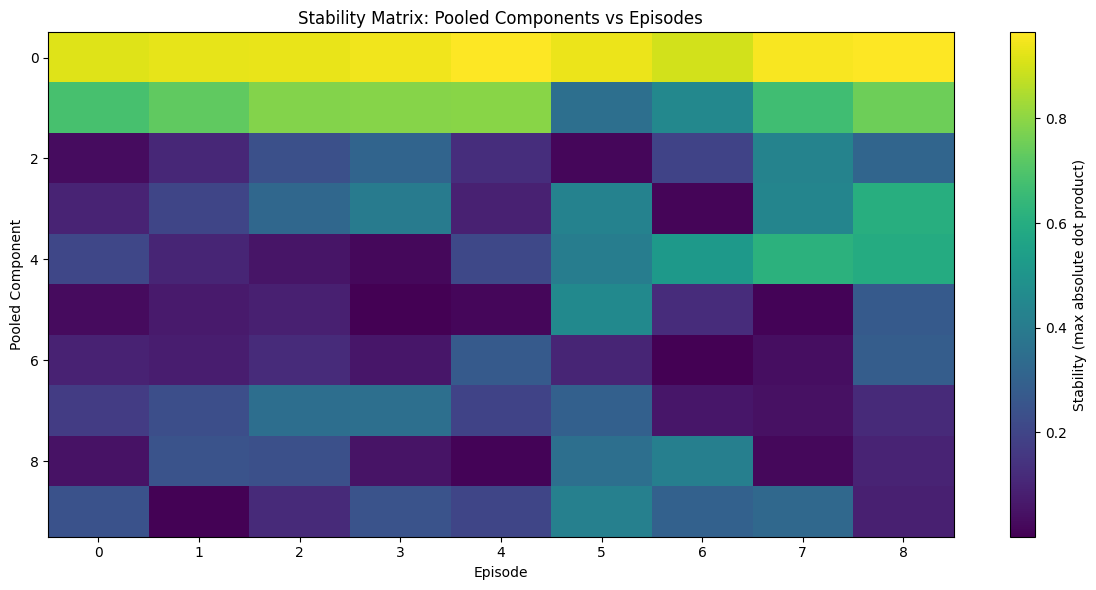

In [59]:
plt.figure(figsize=(12, 6))
plt.imshow(stability, aspect='auto', cmap='viridis')
plt.colorbar(label='Stability (max absolute dot product)')
plt.xlabel('Episode')
plt.ylabel('Pooled Component')
plt.title('Stability Matrix: Pooled Components vs Episodes')
plt.tight_layout()
plt.show()

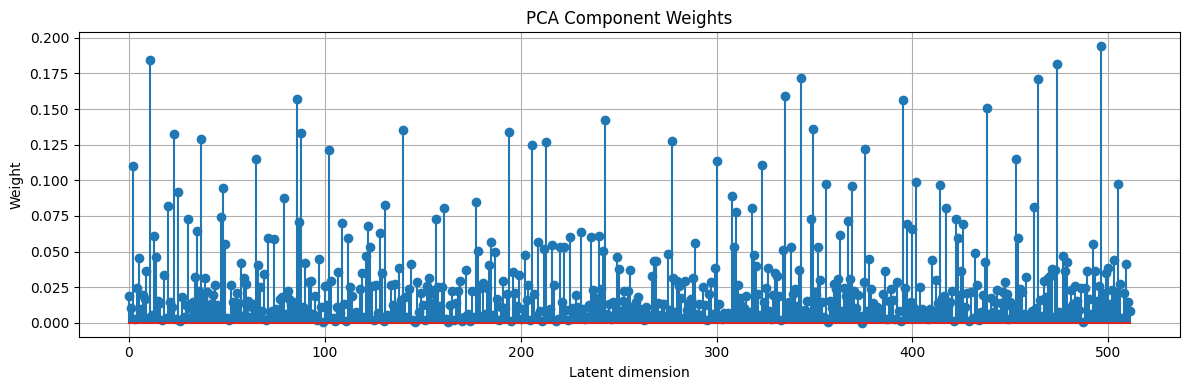

In [61]:
idx = 0
w = comps_pca_all[idx]
plt.figure(figsize=(12, 4))
plt.stem(abs(w))
plt.xlabel('Latent dimension')
plt.ylabel('Weight')
plt.title('PCA Component Weights')
plt.grid(True)
plt.tight_layout()
plt.show()

In [67]:
np.savez('selected_dirs_pca.npz', comps_pca_all=comps_pca_all)